Big Mart Sales Prediction

Importing Dependencies

In [298]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn import metrics

Data Collection and Analysis

In [299]:
big_mart_data = pd.read_csv('big_mart_train.csv')

In [300]:
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [301]:
big_mart_data.shape

(8523, 12)

In [302]:
big_mart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


Cateorical Features : 
Item_Identifier , 
Item_Fat_Content ,
Item_Type ,
Outlet_Identifier , 
Outlet_Size ,
Outlet_Location_Type ,
Outlet_Type

Checking for missing values

In [303]:
big_mart_data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

Handling missing values

In [304]:
big_mart_data["Item_Weight"].mean()

np.float64(12.857645184135977)

In [305]:
big_mart_data["Item_Weight"].fillna(big_mart_data["Item_Weight"].mean(), inplace=True)

C:\Users\Rajasekar\AppData\Local\Temp\ipykernel_9912\2038711501.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  big_mart_data["Item_Weight"].fillna(big_mart_data["Item_Weight"].mean(), inplace=True)


In [306]:
mode_of_outlet_size = big_mart_data.pivot_table(values='Outlet_Size',columns="Outlet_Type",aggfunc=lambda x: x.mode()[0]).iloc[0].to_dict()

In [307]:
print(mode_of_outlet_size)

{'Grocery Store': 'Small', 'Supermarket Type1': 'Small', 'Supermarket Type2': 'Medium', 'Supermarket Type3': 'Medium'}


In [308]:
missing_values = big_mart_data["Outlet_Size"].isnull()

print(missing_values)

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool


In [309]:
big_mart_data.loc[missing_values, "Outlet_Size"] = big_mart_data.loc[missing_values, "Outlet_Type"].map(mode_of_outlet_size)

In [310]:
big_mart_data.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

Data Analysis

In [311]:
big_mart_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


Numerical features 

<Figure size 600x600 with 0 Axes>

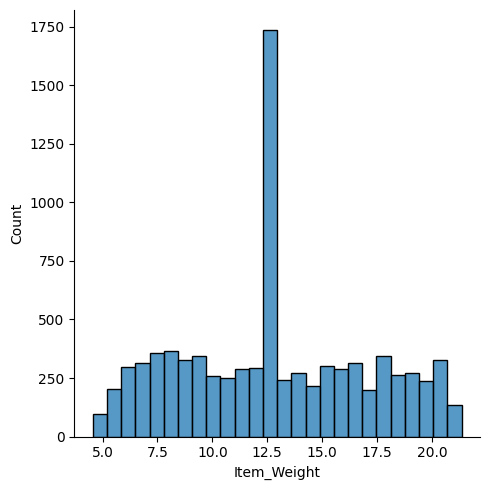

In [312]:
plt.figure(figsize=(6,6))
sns.displot(big_mart_data["Item_Weight"])
plt.show()

<Figure size 600x600 with 0 Axes>

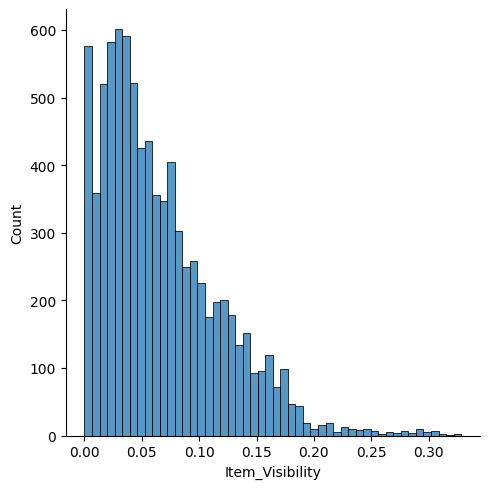

In [313]:
plt.figure(figsize=(6,6))
sns.displot(big_mart_data["Item_Visibility"])
plt.show()

<Figure size 600x600 with 0 Axes>

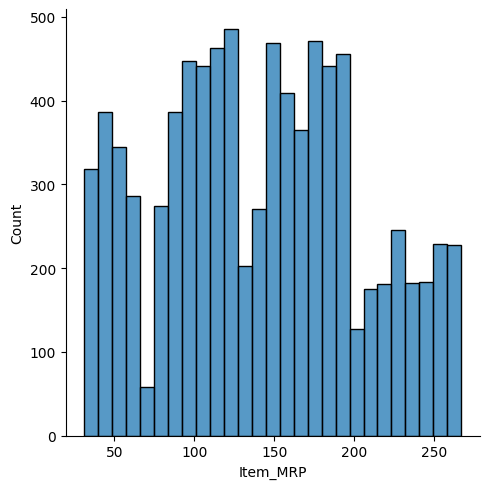

In [314]:
plt.figure(figsize=(6,6))
sns.displot(big_mart_data["Item_MRP"])
plt.show()

<Figure size 600x600 with 0 Axes>

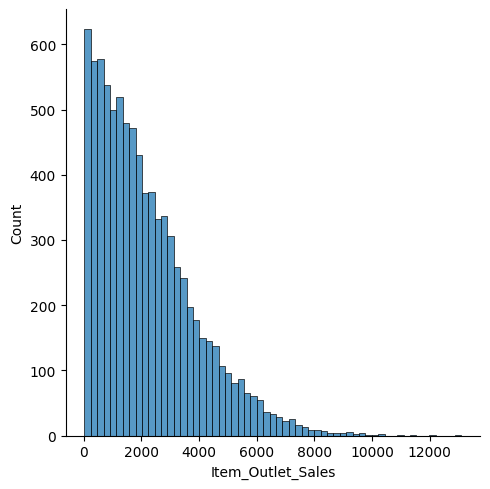

In [315]:
plt.figure(figsize=(6,6))
sns.displot(big_mart_data["Item_Outlet_Sales"])
plt.show()

Distribution of Outlet Establishment Year

C:\Users\Rajasekar\AppData\Local\Temp\ipykernel_9912\3958591176.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Outlet_Establishment_Year",data=big_mart_data,palette="dark")


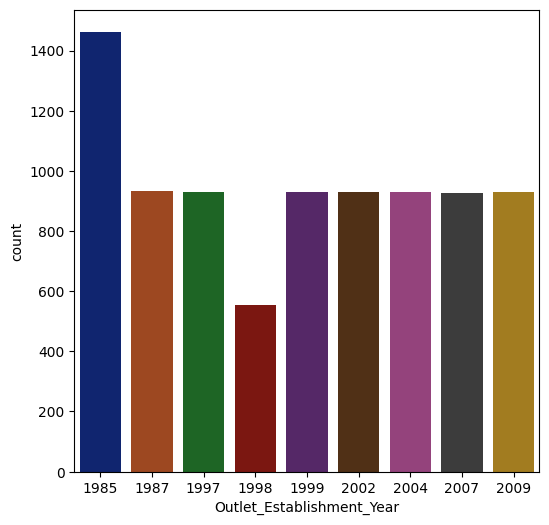

In [316]:
plt.figure(figsize=(6,6))
sns.countplot(x="Outlet_Establishment_Year",data=big_mart_data,palette="dark")
plt.show()

Categorical features

Distribution of Item Fat Content

C:\Users\Rajasekar\AppData\Local\Temp\ipykernel_9912\4156892329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Item_Fat_Content",data=big_mart_data, palette="Set1")


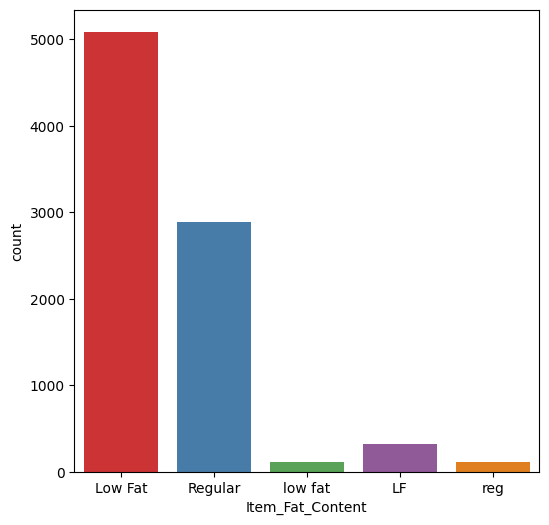

In [317]:
plt.figure(figsize=(6,6))
sns.countplot(x="Item_Fat_Content",data=big_mart_data, palette="Set1")
plt.show()

Distribution of Item Type

C:\Users\Rajasekar\AppData\Local\Temp\ipykernel_9912\2310119601.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Item_Type",data=big_mart_data, palette="muted")


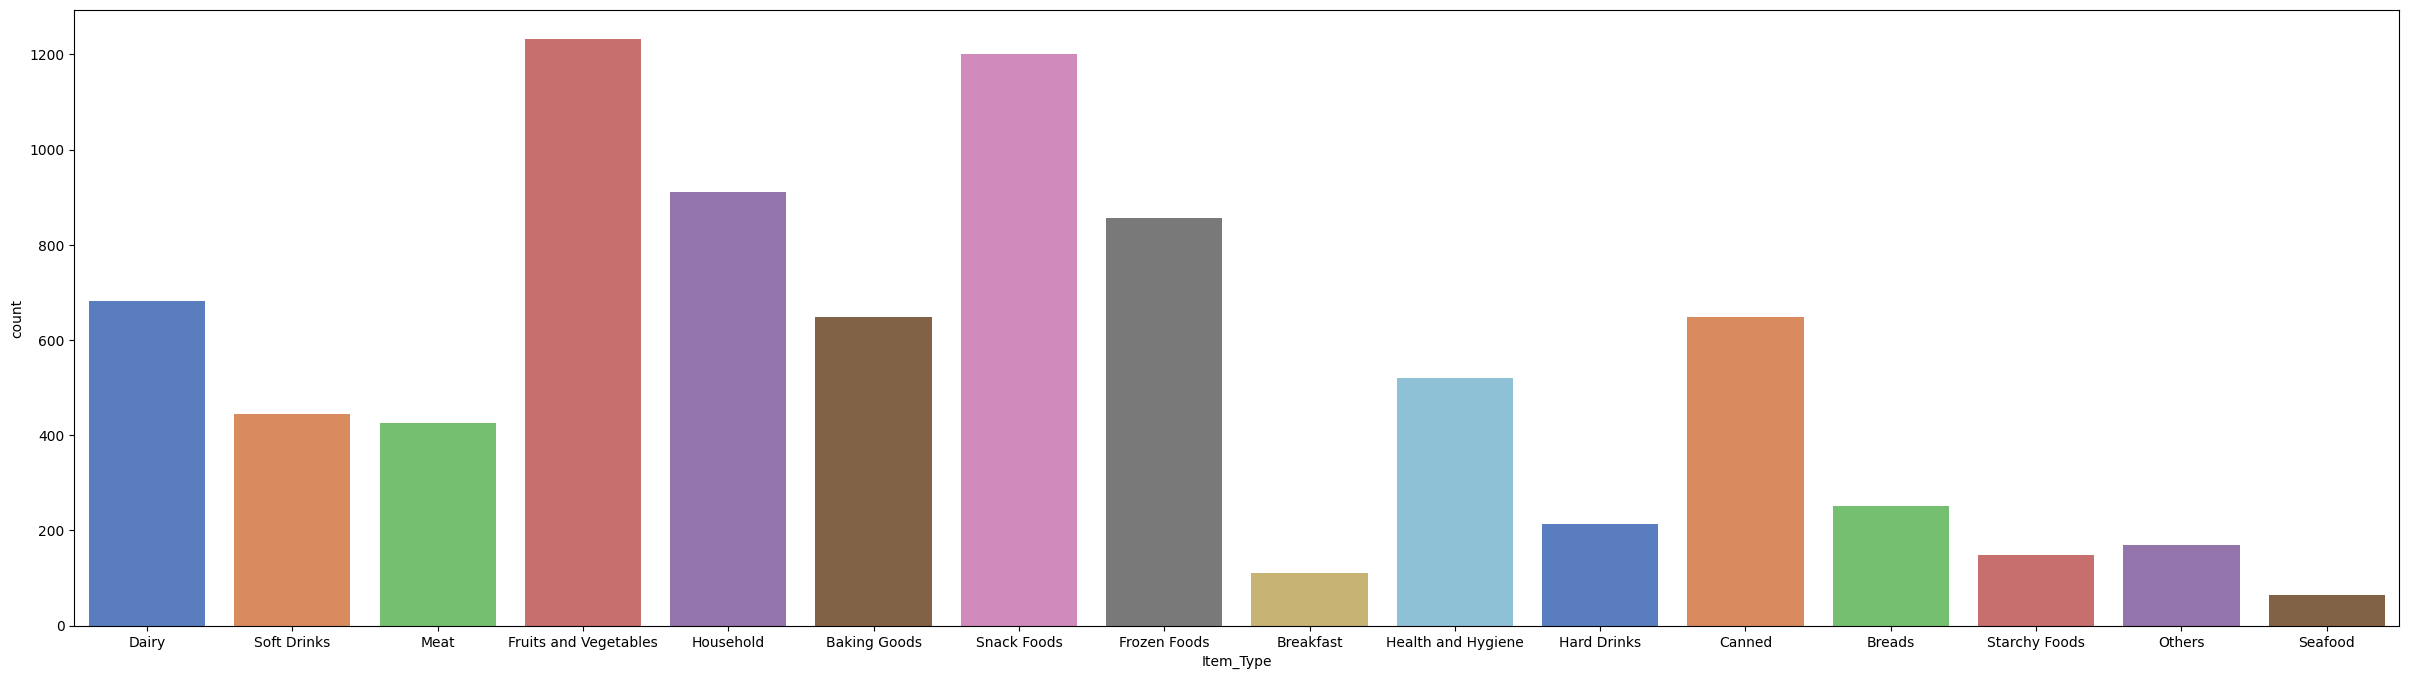

In [318]:
plt.figure(figsize=(30,8))
sns.countplot(x="Item_Type",data=big_mart_data, palette="muted")
plt.show()

Distribution of Outlet Size

C:\Users\Rajasekar\AppData\Local\Temp\ipykernel_9912\3207626265.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=big_mart_data , x="Outlet_Size",palette="deep")


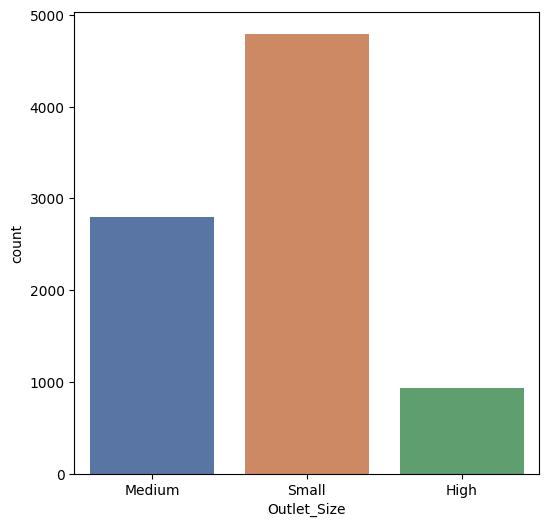

In [319]:
plt.figure(figsize=(6,6))
sns.countplot(data=big_mart_data , x="Outlet_Size",palette="deep")
plt.show()

Data Preprocessing

In [320]:
big_mart_data.shape

(8523, 12)

In [321]:
big_mart_data["Item_Fat_Content"] = big_mart_data["Item_Fat_Content"].map({"low fat":"Low Fat" , "LF":"Low Fat","reg":"Regular","Low Fat":'Low Fat',"Regular":'Regular'})

In [322]:
big_mart_data["Item_Fat_Content"].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

Label Encoding

In [323]:
encoder = LabelEncoder()

In [324]:
big_mart_data["Item_Identifier"] = encoder.fit_transform(big_mart_data["Item_Identifier"])

big_mart_data["Item_Fat_Content"] = encoder.fit_transform(big_mart_data["Item_Fat_Content"])

big_mart_data["Item_Type"] = encoder.fit_transform(big_mart_data["Item_Type"])

big_mart_data["Outlet_Identifier"] = encoder.fit_transform(big_mart_data["Outlet_Identifier"])

big_mart_data["Outlet_Location_Type"] = encoder.fit_transform(big_mart_data["Outlet_Location_Type"])

big_mart_data["Outlet_Type"] = encoder.fit_transform(big_mart_data["Outlet_Type"])

big_mart_data["Outlet_Size"] = encoder.fit_transform(big_mart_data["Outlet_Size"])

In [325]:
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


Separating features and targets

In [326]:
x = big_mart_data.drop(columns="Item_Outlet_Sales",axis=1)

In [327]:
y = big_mart_data["Item_Outlet_Sales"]

In [328]:
print(x)

      Item_Identifier  Item_Weight  Item_Fat_Content  Item_Visibility  \
0                 156        9.300                 0         0.016047   
1                   8        5.920                 1         0.019278   
2                 662       17.500                 0         0.016760   
3                1121       19.200                 1         0.000000   
4                1297        8.930                 0         0.000000   
...               ...          ...               ...              ...   
8518              370        6.865                 0         0.056783   
8519              897        8.380                 1         0.046982   
8520             1357       10.600                 0         0.035186   
8521              681        7.210                 1         0.145221   
8522               50       14.800                 0         0.044878   

      Item_Type  Item_MRP  Outlet_Identifier  Outlet_Establishment_Year  \
0             4  249.8092                  9    

In [329]:
print(y)

0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64


Splitting data into training data and test data

In [330]:
x_train , x_test , y_train , y_test = train_test_split(x , y ,test_size = 0.2, random_state=2)

In [331]:
print(x.shape , x_train.shape , x_test.shape)

(8523, 11) (6818, 11) (1705, 11)


Model Training 

In [332]:
regressor = XGBRegressor(max_depth=4,            # Reduce tree depth (stops memorizing noise)
    learning_rate=0.05,     # Lower step size (requires more trees to learn slowly)
    n_estimators=150,       # Total number of trees
    reg_lambda=3,          # L2 regularization penalty on weights
    reg_alpha=0.5,            # L1 regularization penalty on weights
    random_state=42)

In [333]:
regressor.fit(x_train , y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

Model Evaluation

In [334]:
x_train_prediction = regressor.predict(x_train)

In [335]:
r2_train = metrics.r2_score(y_train , x_train_prediction)

print("R Squared Error :",r2_train)

R Squared Error : 0.6449571742490784


In [336]:
x_test_prediction = regressor.predict(x_test)

In [337]:
r2_test = metrics.r2_score(y_test , x_test_prediction)

print("R Squared Error :",r2_test)

R Squared Error : 0.5863506795283857
